## 1. Data cleaning and Exploratory Data Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("../data/flight_delay_jan2025.csv")
df.head()

,YEAR,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME_BLK,CRS_ARR_TIME,ARR_TIME,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE,DISTANCE_GROUP
0,2025,1,3,1/1/2025 12:00:00 AM,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",659,0600-0659,1020,1013.0,0.0,0.0,0.0,0.0,381.0,2475.0,10
1,2025,1,3,1/1/2025 12:00:00 AM,AA,10,LAX,"Los Angeles, CA",JFK,"New York, NY",2200,2200-2259,630,543.0,0.0,0.0,0.0,0.0,330.0,2475.0,10
2,2025,1,3,1/1/2025 12:00:00 AM,AA,1002,MSN,"Madison, WI",CLT,"Charlotte, NC",644,0600-0659,1005,1025.0,20.0,1.0,0.0,0.0,141.0,708.0,3
3,2025,1,3,1/1/2025 12:00:00 AM,AA,1004,PHL,"Philadelphia, PA",LAS,"Las Vegas, NV",1855,1800-1859,2134,2127.0,0.0,0.0,0.0,0.0,339.0,2176.0,9
4,2025,1,3,1/1/2025 12:00:00 AM,AA,1005,ORD,"Chicago, IL",PHX,"Phoenix, AZ",830,0800-0859,1131,1215.0,44.0,1.0,0.0,0.0,241.0,1440.0,6


In [7]:
df.shape

(539747, 21)

In [8]:
df.columns

Index(['YEAR', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER',
       'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST',
       'DEST_CITY_NAME', 'CRS_DEP_TIME', 'DEP_TIME_BLK', 'CRS_ARR_TIME',
       'ARR_TIME', 'ARR_DELAY_NEW', 'ARR_DEL15', 'CANCELLED', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'DISTANCE', 'DISTANCE_GROUP'],
      dtype='str')

## 2. Data Set Overview

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   YEAR               539747 non-null  int64  
 1   DAY_OF_MONTH       539747 non-null  int64  
 2   DAY_OF_WEEK        539747 non-null  int64  
 3   FL_DATE            539747 non-null  str    
 4   OP_UNIQUE_CARRIER  539747 non-null  str    
 5   OP_CARRIER_FL_NUM  539747 non-null  int64  
 6   ORIGIN             539747 non-null  str    
 7   ORIGIN_CITY_NAME   539747 non-null  str    
 8   DEST               539747 non-null  str    
 9   DEST_CITY_NAME     539747 non-null  str    
 10  CRS_DEP_TIME       539747 non-null  int64  
 11  DEP_TIME_BLK       539747 non-null  str    
 12  CRS_ARR_TIME       539747 non-null  int64  
 13  ARR_TIME           523167 non-null  float64
 14  ARR_DELAY_NEW      522269 non-null  float64
 15  ARR_DEL15          522269 non-null  float64
 16  CANCELLED    

In [12]:
df.isnull().sum()

YEAR                     0
DAY_OF_MONTH             0
DAY_OF_WEEK              0
FL_DATE                  0
OP_UNIQUE_CARRIER        0
OP_CARRIER_FL_NUM        0
ORIGIN                   0
ORIGIN_CITY_NAME         0
DEST                     0
DEST_CITY_NAME           0
CRS_DEP_TIME             0
DEP_TIME_BLK             0
CRS_ARR_TIME             0
ARR_TIME             16580
ARR_DELAY_NEW        17478
ARR_DEL15            17478
CANCELLED                0
DIVERTED                 0
CRS_ELAPSED_TIME         0
DISTANCE                 0
DISTANCE_GROUP           0
dtype: int64

In [14]:
df.describe()

,YEAR,DAY_OF_MONTH,DAY_OF_WEEK,OP_CARRIER_FL_NUM,CRS_DEP_TIME,CRS_ARR_TIME,ARR_TIME,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE,DISTANCE_GROUP
count,539747.0,539747.000000,539747.000000,539747.000000,539747.000000,539747.000000,523167.000000,522269.000000,522269.000000,539747.000000,539747.000000,539747.000000,539747.000000,539747.000000
mean,2025.0,15.831995,4.019748,2492.102685,1315.739317,1502.662084,1482.305705,14.218872,0.187892,0.030222,0.002160,151.410600,843.208216,3.843271
std,0.0,9.036782,1.925782,1669.518460,480.555061,502.478468,520.043174,53.054696,0.390626,0.171197,0.046429,73.812226,599.092323,2.335166
min,2025.0,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,25.000000,31.000000,1.000000
25%,2025.0,8.000000,2.000000,1113.000000,905.000000,1117.000000,1106.000000,0.000000,0.000000,0.000000,0.000000,96.000000,403.000000,2.000000
50%,2025.0,16.000000,4.000000,2213.000000,1310.000000,1524.000000,1515.000000,0.000000,0.000000,0.000000,0.000000,135.000000,701.000000,3.000000
75%,2025.0,24.000000,6.000000,3695.000000,1725.000000,1924.000000,1917.000000,7.000000,0.000000,0.000000,0.000000,183.000000,1083.000000,5.000000
max,2025.0,31.000000,7.000000,8819.000000,2359.000000,2359.000000,2400.000000,3282.000000,1.000000,1.000000,1.000000,693.000000,5095.000000,11.000000


## 3. Checking Cancelled and Diverted Flights

There are a plenty of missing values in ARR_DEL15, ARR_DELAY_NEW and ARR_TIME. This is due to the diverted and cancelled flights. Before building a delay prediction model, we need to check cancelled and diverted flights.

In [19]:
df["CANCELLED"].value_counts(normalize=True) * 100

CANCELLED
0.0    96.977843
1.0     3.022157
Name: proportion, dtype: float64

In [18]:
df["DIVERTED"].value_counts(normalize=True) * 100

DIVERTED
0.0    99.783973
1.0     0.216027
Name: proportion, dtype: float64

In [21]:
missing_target = df[df["ARR_DEL15"].isnull()]

missing_target[["CANCELLED", "DIVERTED"]].value_counts()

CANCELLED  DIVERTED
1.0        0.0         16312
0.0        1.0          1166
Name: count, dtype: int64

##. 4. Removing Cancelled and Diverted Flights

The target variable for this project is whether a flight arrived 15 minutes or more late. Cancelled and diverted flights do not have a normal arrival delay outcome, so they are removed from the modelling dataset.

In [22]:
df_clean = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] ==0)].copy()

df_clean.shape

(522269, 21)

In [25]:
df_clean.isnull().sum()

YEAR                 0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
FL_DATE              0
OP_UNIQUE_CARRIER    0
OP_CARRIER_FL_NUM    0
ORIGIN               0
ORIGIN_CITY_NAME     0
DEST                 0
DEST_CITY_NAME       0
CRS_DEP_TIME         0
DEP_TIME_BLK         0
CRS_ARR_TIME         0
ARR_TIME             0
ARR_DELAY_NEW        0
ARR_DEL15            0
CANCELLED            0
DIVERTED             0
CRS_ELAPSED_TIME     0
DISTANCE             0
DISTANCE_GROUP       0
dtype: int64

In [26]:
df_clean["ARR_DEL15"].isnull().sum()

np.int64(0)

In [27]:
df_clean["ARR_DEL15"] = df_clean["ARR_DEL15"].astype(int)

In [28]:
df_clean["ARR_DEL15"].value_counts()

ARR_DEL15
0    424139
1     98130
Name: count, dtype: int64

In [29]:
df_clean["ARR_DEL15"].value_counts(normalize=True) * 100

ARR_DEL15
0    81.210832
1    18.789168
Name: proportion, dtype: float64

## 5. Target Variable Distribution

After removing cancelled and diverted flights, the dataset contains 522,269 completed flights. Most flights were not delayed. Around 81% of flights arrived on time, while around 19% arrived 15 minutes or more late. This means the dataset is somewhat imbalanced, so model evaluation should use more than accuracy alone.

## 6. Delay Rate By Airline

In [32]:
airline_delay = df_clean.groupby("OP_UNIQUE_CARRIER")["ARR_DEL15"].mean().sort_values(ascending=False) * 100

airline_delay

OP_UNIQUE_CARRIER
F9    25.976175
OH    25.481698
B6    24.456088
G4    23.712796
OO    20.882807
DL    19.320500
AA    19.228101
MQ    18.429264
NK    18.080963
UA    17.627085
AS    17.577184
YX    16.017689
WN    15.208578
HA    13.547401
Name: ARR_DEL15, dtype: float64

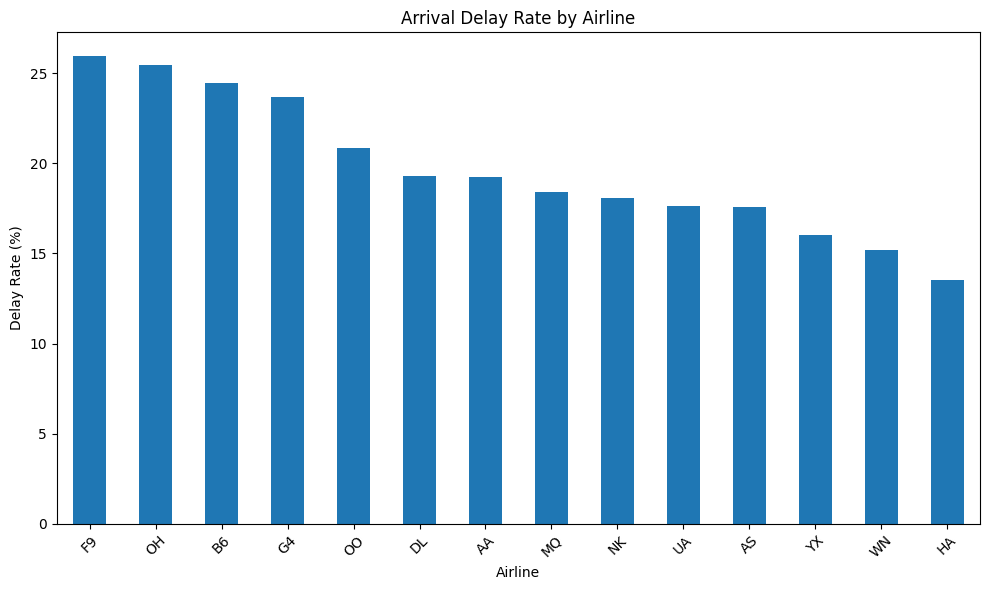

In [34]:
plt.figure(figsize=(10, 6))
airline_delay.plot(kind="bar")
plt.title("Arrival Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/delay_rate_by_airline.png", dpi=300)
plt.show()

### Airline Delay Rate

The delay rate varies across airlines. In this dataset, F9, OH, B6, and G4 had the highest percentage of flights arriving 15 minutes or more late, while HA, WN, and YX had the lowest delay rates.

However, this does not necessarily mean that one airline is operationally worse than another. Delay rates may also be affected by the routes served, airport congestion, weather conditions, flight timing, and other external factors.

In [35]:
airline_summary = df_clean.groupby("OP_UNIQUE_CARRIER").agg(
    total_flights=("ARR_DEL15", "count"),
    delayed_flights=("ARR_DEL15", "sum"),
    delay_rate_percent=("ARR_DEL15", "mean")
).sort_values("delay_rate_percent", ascending=False)

airline_summary["delay_rate_percent"] = airline_summary["delay_rate_percent"] * 100

airline_summary

,total_flights,delayed_flights,delay_rate_percent
OP_UNIQUE_CARRIER,,,
F9,15110,3925,25.976175
OH,19151,4880,25.481698
B6,17558,4294,24.456088
G4,9206,2183,23.712796
OO,63502,13261,20.882807
DL,74025,14302,19.320500
AA,72082,13860,19.228101
MQ,20831,3839,18.429264
NK,16946,3064,18.080963


In [36]:
airline_summary.to_csv("../results/airline_delay_summary.csv")

## 7. Delay Rate by Scheduled Departure Timing

In [37]:
time_block_delay = df_clean.groupby("DEP_TIME_BLK")["ARR_DEL15"].mean().sort_index() * 100

time_block_delay

DEP_TIME_BLK
0001-0559    12.550243
0600-0659    12.563156
0700-0759    14.666484
0800-0859    15.529880
0900-0959    15.651535
1000-1059    17.314951
1100-1159    17.551102
1200-1259    18.903887
1300-1359    19.110301
1400-1459    20.534003
1500-1559    21.561121
1600-1659    22.026931
1700-1759    21.956914
1800-1859    22.466852
1900-1959    23.185415
2000-2059    23.492789
2100-2159    22.854999
2200-2259    21.517940
2300-2359    14.446890
Name: ARR_DEL15, dtype: float64

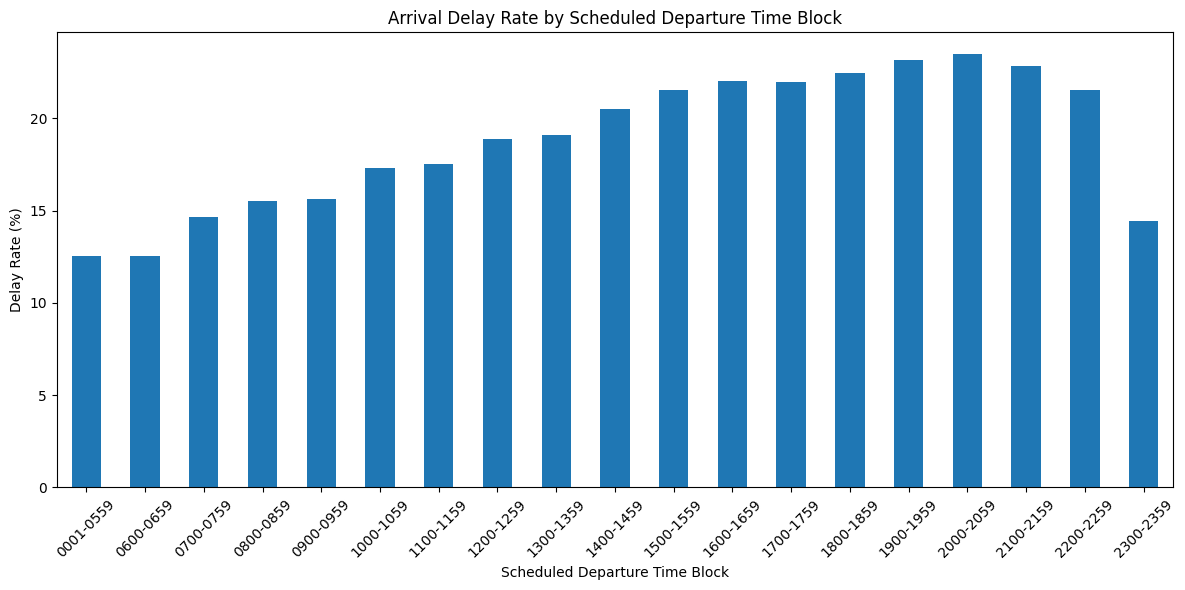

In [38]:
plt.figure(figsize=(12, 6))
time_block_delay.plot(kind="bar")
plt.title("Arrival Delay Rate by Scheduled Departure Time Block")
plt.xlabel("Scheduled Departure Time Block")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/delay_rate_by_departure_time_block.png", dpi=300)
plt.show()

### Delay Rate by Scheduled Departure Time

The delay rate generally increases as the day progresses. Early morning flights have the lowest delay rates, while evening flights have the highest delay rates.

This suggests that delays may accumulate throughout the day as aircraft, crew, and airport operations are affected by earlier disruptions. However, this chart only shows correlation and does not prove that departure time directly causes delays.

In [39]:
time_block_summary = df_clean.groupby("DEP_TIME_BLK").agg(
    total_flights=("ARR_DEL15", "count"),
    delayed_flights=("ARR_DEL15", "sum"),
    delay_rate_percent=("ARR_DEL15", "mean")
)

time_block_summary["delay_rate_percent"] = time_block_summary["delay_rate_percent"] * 100

time_block_summary

,total_flights,delayed_flights,delay_rate_percent
DEP_TIME_BLK,,,
0001-0559,14430,1811,12.550243
0600-0659,35230,4426,12.563156
0700-0759,36580,5365,14.666484
0800-0859,37650,5847,15.529880
0900-0959,31326,4903,15.651535
1000-1059,32059,5551,17.314951
1100-1159,34881,6122,17.551102
1200-1259,32004,6050,18.903887
1300-1359,31831,6083,19.110301


In [ ]:
time_block_summary.to_csv("../results/time_block_delay_summary.csv") 

## 8. Delay Rate by Day of Week

In [41]:
day_delay = df_clean.groupby("DAY_OF_WEEK")["ARR_DEL15"].mean() * 100

day_delay

DAY_OF_WEEK
1    22.638787
2    15.312897
3    13.280143
4    17.367965
5    19.462396
6    21.639186
7    22.594496
Name: ARR_DEL15, dtype: float64

In [43]:
# Swapping numbers with day names on x-axis for better coherence
day_names = {
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun"
}

day_delay_named = day_delay.rename(index=day_names)

day_delay_named

DAY_OF_WEEK
Mon    22.638787
Tue    15.312897
Wed    13.280143
Thu    17.367965
Fri    19.462396
Sat    21.639186
Sun    22.594496
Name: ARR_DEL15, dtype: float64

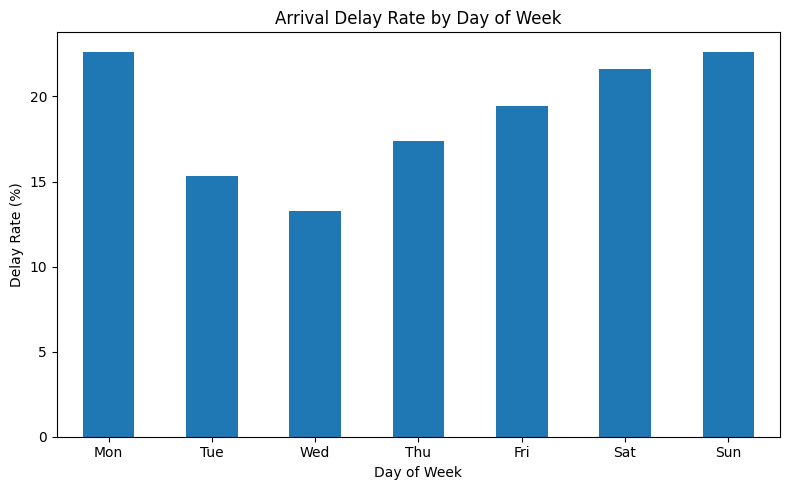

In [45]:
plt.figure(figsize=(8, 5))
day_delay_named.plot(kind="bar")
plt.title("Arrival Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../charts/delay_rate_by_day_of_week.png", dpi=300)
plt.show()

## 9. Delay Rate by Origin Airport

In [47]:
origin_delay = df_clean.groupby("ORIGIN").agg(
    total_flights=("ARR_DEL15", "count"),
    delayed_flights=("ARR_DEL15", "sum"),
    delay_rate_percent=("ARR_DEL15", "mean")
)

origin_delay["delay_rate_percent"] = origin_delay["delay_rate_percent"] * 100

origin_delay = origin_delay.sort_values("delay_rate_percent", ascending=False)

origin_delay.head(20)

,total_flights,delayed_flights,delay_rate_percent
ORIGIN,,,
CKB,9,7,77.777778
SCE,16,9,56.250000
TOL,30,14,46.666667
MGW,46,21,45.652174
SMX,9,4,44.444444
BRW,28,12,42.857143
COD,61,25,40.983607
USA,49,20,40.816327
TVC,268,107,39.925373


### Using airports with more than a 1000 flighs as some airports may have very few flights, leading to an extreme delay rate

In [ ]:
origin_delay_filtered = origin_delay[origin_delay["total_flights"] >= 1000]

origin_delay_filtered.head(20)

,total_flights,delayed_flights,delay_rate_percent
ORIGIN,,,
GRR,1312,342,26.067073
SJU,3139,808,25.740682
BUF,1355,341,25.166052
DEN,24350,6074,24.944559
PIT,3001,740,24.658447
PHL,6492,1594,24.553296
DTW,9102,2219,24.379257
CLE,2858,681,23.827852
DCA,10619,2478,23.335531


In [55]:
# Save origin airport summary
origin_delay_filtered.to_csv("../results/origin_airport_delay_summary.csv")

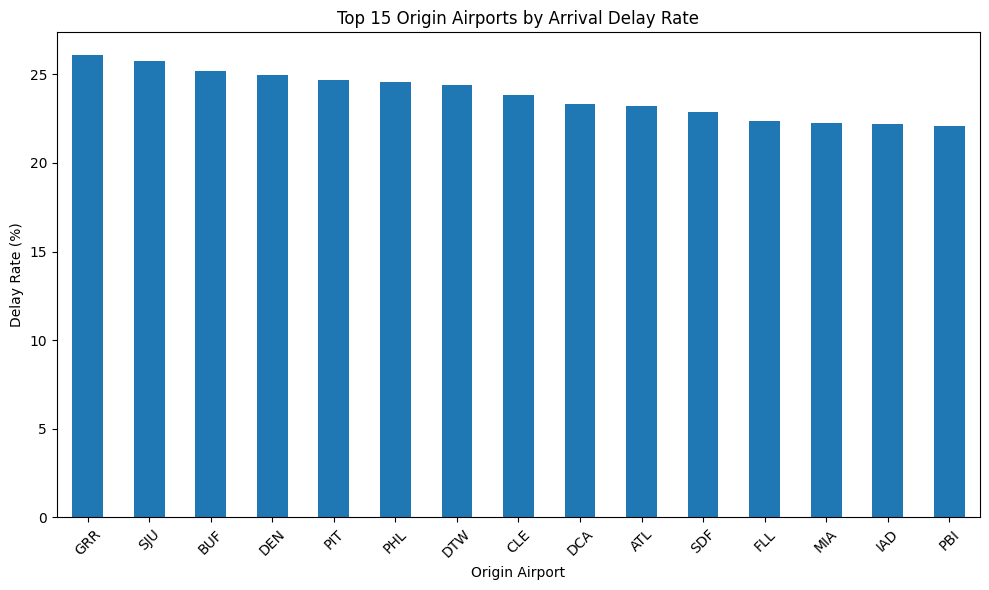

In [50]:
top_origin_delay = origin_delay_filtered.head(15)

plt.figure(figsize=(10, 6))
top_origin_delay["delay_rate_percent"].plot(kind="bar")
plt.title("Top 15 Origin Airports by Arrival Delay Rate")
plt.xlabel("Origin Airport")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/top_origin_airports_by_delay_rate.png", dpi=300)
plt.show()

### Delay Rate by Origin Airport

After filtering for origin airports with at least 1,000 completed flights, GRR, SJU, BUF, DEN, and PIT had the highest arrival delay rates in this dataset.

This suggests that departure airport may be associated with delay risk. However, this does not necessarily mean the airport itself caused the delay, since delay rates can also be affected by airline, route, weather, flight timing, and other operational factors.

## 10. Delay Rate by Destination Airport

In [52]:
dest_delay = df_clean.groupby("DEST").agg(
    total_flights=("ARR_DEL15", "count"),
    delayed_flights=("ARR_DEL15", "sum"),
    delay_rate_percent=("ARR_DEL15", "mean")
)

dest_delay["delay_rate_percent"] = dest_delay["delay_rate_percent"] * 100

dest_delay = dest_delay.sort_values("delay_rate_percent", ascending=False)

dest_delay_filtered = dest_delay[dest_delay["total_flights"] >= 1000]

dest_delay_filtered.head(20)

,total_flights,delayed_flights,delay_rate_percent
DEST,,,
PBI,2886,838,29.036729
SJU,3128,839,26.822251
BUF,1349,325,24.091920
ANC,1162,279,24.010327
FLL,7698,1787,23.213822
PVD,1076,248,23.048327
CVG,2296,512,22.299652
TPA,6323,1391,21.999051
RSW,3487,766,21.967307


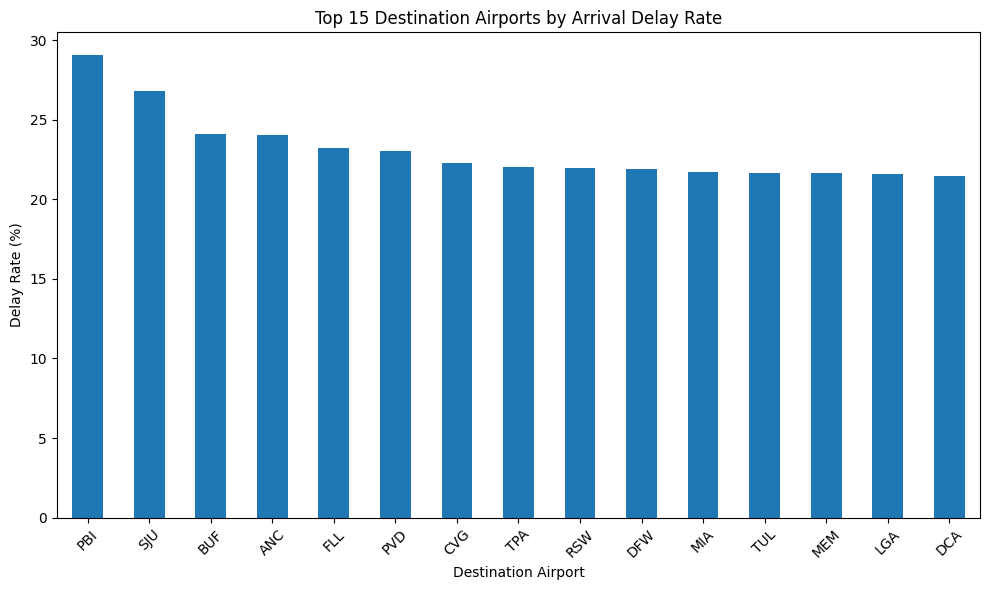

In [53]:
top_dest_delay = dest_delay_filtered.head(15)

plt.figure(figsize=(10, 6))
top_dest_delay["delay_rate_percent"].plot(kind="bar")
plt.title("Top 15 Destination Airports by Arrival Delay Rate")
plt.xlabel("Destination Airport")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/top_destination_airports_by_delay_rate.png", dpi=300)
plt.show()

In [54]:
dest_delay_filtered.to_csv("../results/destination_airport_delay_summary.csv")

### Delay Rate by Destination Airport

After filtering for destination airports with at least 1,000 completed flights, PBI, SJU, BUF, ANC, and FLL had the highest arrival delay rates.

This suggests that destination airport may be associated with arrival delay risk. However, the result should be interpreted carefully because airport delay rates can also be influenced by route mix, airline mix, weather, airport congestion, and other operational factors.

## 11. Delay Rate by Distance Group

In [56]:
distance_delay = df_clean.groupby("DISTANCE_GROUP").agg(
    total_flights=("ARR_DEL15", "count"),
    delayed_flights=("ARR_DEL15", "sum"),
    delay_rate_percent=("ARR_DEL15", "mean")
)

distance_delay["delay_rate_percent"] = distance_delay["delay_rate_percent"] * 100

distance_delay

,total_flights,delayed_flights,delay_rate_percent
DISTANCE_GROUP,,,
1,58884,10634,18.059235
2,115496,20681,17.906248
3,100092,19441,19.423131
4,87398,17031,19.486716
5,66475,13772,20.717563
6,25293,4633,18.317321
7,24533,4893,19.944564
8,11677,2021,17.307528
9,8993,1473,16.379406


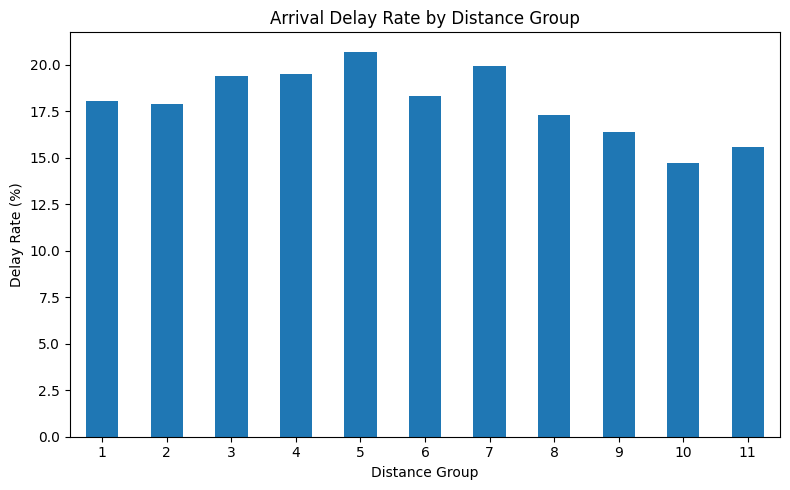

In [57]:
plt.figure(figsize=(8, 5))
distance_delay["delay_rate_percent"].plot(kind="bar")
plt.title("Arrival Delay Rate by Distance Group")
plt.xlabel("Distance Group")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../charts/delay_rate_by_distance_group.png", dpi=300)
plt.show()

### Delay Rate by Distance Group

Delay rates vary by distance group, but the pattern is not strictly increasing or decreasing. Medium-distance flights appear to have slightly higher delay rates, while some longer-distance groups have lower delay rates.

This suggests that distance may be related to delay risk, but distance alone is unlikely to fully explain arrival delays. Other factors such as airline, route, airport congestion, and scheduled departure time are also likely important.

## 12. Delay Rate by Group

In [58]:
df_clean["ROUTE"] = df_clean["ORIGIN"] + "-" + df_clean["DEST"]

df_clean[["ORIGIN", "DEST", "ROUTE"]].head()

,ORIGIN,DEST,ROUTE
0,JFK,LAX,JFK-LAX
1,LAX,JFK,LAX-JFK
2,MSN,CLT,MSN-CLT
3,PHL,LAS,PHL-LAS
4,ORD,PHX,ORD-PHX


In [59]:
route_delay = df_clean.groupby("ROUTE").agg(
    total_flights=("ARR_DEL15", "count"),
    delayed_flights=("ARR_DEL15", "sum"),
    delay_rate_percent=("ARR_DEL15", "mean")
)

route_delay["delay_rate_percent"] = route_delay["delay_rate_percent"] * 100

route_delay = route_delay.sort_values("delay_rate_percent", ascending=False)

route_delay_filtered = route_delay[route_delay["total_flights"] >= 100]

route_delay_filtered.head(20)

,total_flights,delayed_flights,delay_rate_percent
ROUTE,,,
ORD-ASE,139,63,45.323741
HSV-DFW,161,72,44.720497
DEN-MAF,117,50,42.735043
BOS-PBI,236,99,41.949153
DTW-MIA,141,56,39.716312
EGE-DFW,121,47,38.842975
DEN-BIS,124,48,38.709677
BOS-IAH,109,42,38.532110
ASE-ORD,138,53,38.405797


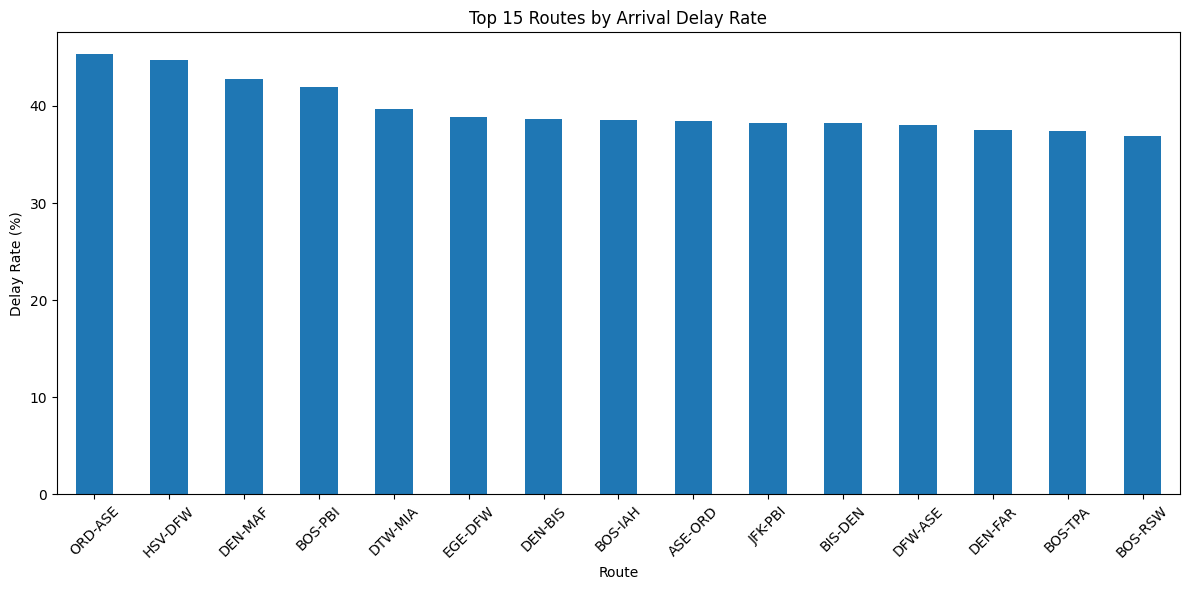

In [60]:
top_route_delay = route_delay_filtered.head(15)

plt.figure(figsize=(12, 6))
top_route_delay["delay_rate_percent"].plot(kind="bar")
plt.title("Top 15 Routes by Arrival Delay Rate")
plt.xlabel("Route")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/top_routes_by_delay_rate.png", dpi=300)
plt.show()

### Delay Rate by Route

Some routes had much higher delay rates than the overall dataset average. Among routes with at least 100 completed flights, ORD-ASE, HSV-DFW, DEN-MAF, and BOS-PBI had the highest observed arrival delay rates.

However, route-level delay rates should be interpreted carefully because some routes have relatively small sample sizes. A few delayed flights can have a larger effect on the delay rate for routes with fewer total flights.

## 13. Saving Cleaned Dataset

In [61]:
df_clean.columns

Index(['YEAR', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER',
       'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST',
       'DEST_CITY_NAME', 'CRS_DEP_TIME', 'DEP_TIME_BLK', 'CRS_ARR_TIME',
       'ARR_TIME', 'ARR_DELAY_NEW', 'ARR_DEL15', 'CANCELLED', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'DISTANCE', 'DISTANCE_GROUP', 'ROUTE'],
      dtype='str')

In [63]:
df_clean.to_csv("../data/cleaned_flight_delay_data.csv", index=False)

In [64]:
pd.read_csv("../data/cleaned_flight_delay_data.csv").head()

,YEAR,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME_BLK,CRS_ARR_TIME,ARR_TIME,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE,DISTANCE_GROUP,ROUTE
0,2025,1,3,1/1/2025 12:00:00 AM,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",659,0600-0659,1020,1013.0,0.0,0,0.0,0.0,381.0,2475.0,10,JFK-LAX
1,2025,1,3,1/1/2025 12:00:00 AM,AA,10,LAX,"Los Angeles, CA",JFK,"New York, NY",2200,2200-2259,630,543.0,0.0,0,0.0,0.0,330.0,2475.0,10,LAX-JFK
2,2025,1,3,1/1/2025 12:00:00 AM,AA,1002,MSN,"Madison, WI",CLT,"Charlotte, NC",644,0600-0659,1005,1025.0,20.0,1,0.0,0.0,141.0,708.0,3,MSN-CLT
3,2025,1,3,1/1/2025 12:00:00 AM,AA,1004,PHL,"Philadelphia, PA",LAS,"Las Vegas, NV",1855,1800-1859,2134,2127.0,0.0,0,0.0,0.0,339.0,2176.0,9,PHL-LAS
4,2025,1,3,1/1/2025 12:00:00 AM,AA,1005,ORD,"Chicago, IL",PHX,"Phoenix, AZ",830,0800-0859,1131,1215.0,44.0,1,0.0,0.0,241.0,1440.0,6,ORD-PHX
